In [16]:
import random
import numpy as np
from scipy.integrate import solve_ivp
import pandas as pd
from scipy.optimize import differential_evolution
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import matplotlib as mpl

seed=1
random.seed(seed)
np.random.seed(seed)

### Define and solve the system

In [17]:
def system(_t, y, params):
    r, w, v = y
    omega, kappa, v_w, k1, k2, sigma, gamma, phi = params

    h = max(r + w + v, 1e-8)

    d_r = -omega * r - (sigma * k1 / h) * r * v + kappa * w + (gamma * k2 / h) * r * v
    d_w = omega * r + (sigma * k1 / h) * r * v - kappa * w - v_w * w
    d_v = v_w * w - (gamma * k2 / h) * r * v + phi * h

    return [d_r, d_w, d_v]


def solve_model(params, t_eval_sol, y0_sol):
    sol = solve_ivp(
        system,
        (t_eval_sol[0], t_eval_sol[-1]),
        y0_sol,
        args=(params,),
        t_eval=t_eval_sol,
        method="RK45")

    if not sol.success:
        raise RuntimeError("ODE solver failed")

    r_sol, w_sol, v_sol = sol.y
    return r_sol, w_sol, v_sol

### Data vacancies

In [18]:
### Load data
data_path = r"...\dfMSA_with_type.csv"  # Data path
df = pd.read_csv(data_path) # Load the data for all MSAs

In [19]:
df = df.sort_values(by=["MAS_Code", "year"])    # Sort data

mas_code = "C4098"  # Pick MSA
df_sub = df[df["MAS_Code"] == mas_code] # Get MSA

years = df_sub["year"].values   # Time points
t_eval = np.linspace(0, years[-1] - years[0], len(years))       # Time

o_data = df_sub["Occupied"].values   # R + W - Occupied
v_data = df_sub["Vacant"].values        # V - Vacancy

occupied = df_sub["Occupied"].iloc[0]   # Occupied
r0 = int(round(occupied * 0.9)) # R initial condition
w0 = occupied - r0  # W initial condition

y0 = [r0, w0, df_sub["Vacant"].iloc[0]]   # Initial conditions
N0 = df_sub["POPESTIMATE"].iloc[0]    # Total housing

Loss function

In [20]:
def loss(params, years_loss, o_data_loss, y_data, y0_loss):
    try:
        params10 = np.array([
            10**params[0],            # omega
            10**params[1],            # kappa
            10**params[2],            # v_w
            params[3],                # k1
            params[4],                # k2
            10**params[5],            # sigma
            10**params[6],            # gamma
            params[7]                 # phi
        ], dtype=float)

        r_loss, w_loss, v_loss = solve_model(params10, years_loss, y0_loss)
    except (RuntimeError, ValueError):
        return 1e12  # "Ignore" failed attempts

    if np.any(np.isnan(r_loss)) or np.any(np.isnan(w_loss)) or np.any(np.isnan(v_loss)):
        return 1e12 # "Ignore" failed attempts

    o_model_loss = r_loss + w_loss   # R + W - Occupied

    # Normalize
    o_err = (o_model_loss - o_data_loss) / np.max(o_data_loss)
    y_err = (v_loss - y_data) / np.max(y_data)

    # Penalize for varying R/W
    rw_ratio = r_loss / np.maximum(w_loss, 1e-8)    # "Safe" ratio
    rw_derivative = np.diff(rw_ratio) / rw_ratio[0] # Normalized derivative
    lambda_deriv = 0.001  # Weight

    # Omega and Sigma are comparable
    similarity_penalty = (params[0] - params[5]) ** 2
    lambda_sim = 0.001  # Weight

    return np.mean(o_err ** 2) + np.mean(y_err ** 2) + lambda_sim * similarity_penalty + lambda_deriv * np.mean(rw_derivative ** 2)


### Optimization

In [21]:
parameters = np.array([
    np.log10(0.1),            # omega
    np.log10(0.239),            # kappa
    np.log10(0.1),            # v_w
    round(N0 ** (1 / 7)),     # k1
    round(N0 ** (1 / 6)),     # k2
    np.log10(0.1),            # sigma
    np.log10(0.1),            # gamma
    0                         # phi
], dtype=float)

bounds = [
    np.log10((0.001, 0.5)),   # omega
    np.log10((0.239, 0.239)),   # kappa
    np.log10((0.001, 0.5)),   # v_w
    (round(N0 ** (1 / 7)), round(N0 ** (1 / 7))),  # k1
    (round(N0 ** (1 / 6)), round(N0 ** (1 / 6))),  # k2
    np.log10((0.001, 0.5)),   # sigma
    np.log10((0.001, 0.5)),   # gamma
    (-0.075, 0.1)          # phi
]

result_global = differential_evolution(
    loss,
    bounds,
    args=(t_eval, o_data, v_data, y0),
    strategy='best1bin',
    maxiter=1000,
    popsize=25,
    tol= 1e-5,
    mutation=(0.5, 1.0),
    recombination=0.7,
    polish=False,
    seed=seed)

result = minimize(
    loss,
    result_global.x,
    args=(t_eval, o_data, v_data, y0),
    method="L-BFGS-B",
    bounds=bounds,
    options={"maxiter": 1000, "ftol": 1e-9, "eps": 1e-4})

params_hat = np.array([
            10**result.x[0],            # omega
            10**result.x[1],            # kappa
            10**result.x[2],            # v_w
            result.x[3],      # k1
            result.x[4],      # k2
            10**result.x[5],            # sigma
            10**result.x[6],            # gamma
            result.x[7]               # phi
        ], dtype=float)
param_names = ["omega", "kappa", "v_w", "k1", "k2", "sigma", "gamma", "phi"]

print("Estimated parameters:")
for name, value in zip(param_names, params_hat):
    print(f"{name} = {value:.6f}")


Estimated parameters:
omega = 0.030498
kappa = 0.239000
v_w = 0.094241
k1 = 6.000000
k2 = 8.000000
sigma = 0.030989
gamma = 0.018495
phi = -0.000524


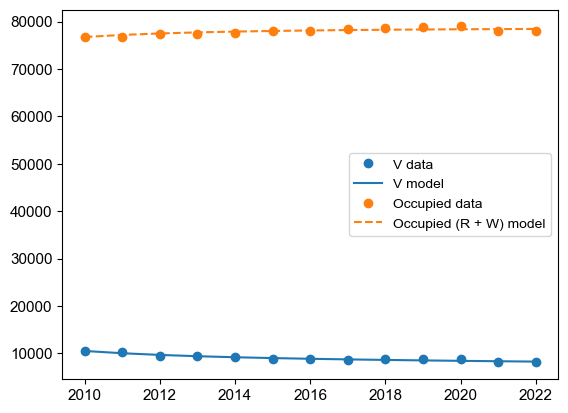

In [22]:
### Check calibration

R, W, V = solve_model(params_hat, t_eval, y0)
o_model = R + W

plt.figure()
color_v = "tab:blue"
color_o = "tab:orange"

plt.plot(years, v_data, 'o', color=color_v, label="V data")
plt.plot(years, V, '-', color=color_v, label="V model")

plt.plot(years, o_data, 'o', color=color_o, label="Occupied data")
plt.plot(years, o_model, '--', color=color_o, label="Occupied (R + W) model")

plt.legend()
plt.show()

In [23]:
### Save

mas_title = df_sub["MAS_Title"].iloc[0]
mas_code = df_sub["MAS_Code"].iloc[0]

base_name = f"{mas_title}({mas_code})"

pdf_name = base_name + " Calibration.pdf"
txt_name = base_name + " Parameters.txt"

with open(txt_name, "w", encoding="utf-8") as f:
    f.write(f"{mas_title} ({mas_code}) Parameters\n\n")
    for name, value in zip(param_names, params_hat):
        f.write(f"{name} = {value:.6f}\n")

### Plot

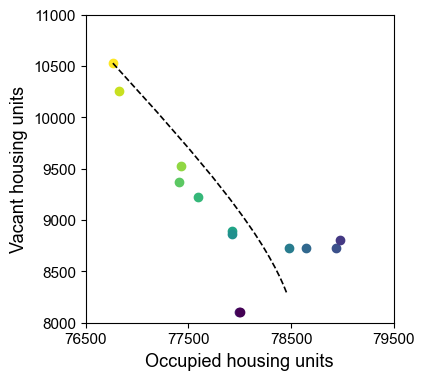

In [24]:
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['axes.labelsize'] = 13   
mpl.rcParams['xtick.labelsize'] = 11
mpl.rcParams['ytick.labelsize'] = 11
mpl.rcParams['text.antialiased'] = True
mpl.rcParams['font.weight'] = 'normal'

plt.figure(figsize=(4, 4))

cmap = plt.cm.viridis_r   # Viridis
colors = cmap(np.linspace(0, 1, len(o_data)))

for i in range(len(o_data)):    # Color the data points
    plt.scatter(o_data[i], v_data[i], color=colors[i], marker='o')

plt.plot(o_model, V, color='black', linewidth=1.2, linestyle='--')   # Black line for the model

ax = plt.gca()
ax.set_box_aspect(1)
ax.set_xticks(np.arange(76500, 79501, 1000))
ax.set_yticks(np.arange(8000, 11001, 500))
ax.set_xlim(76500, 79500)
ax.set_ylim(8000, 11000)
plt.xlabel("Occupied housing units")
plt.ylabel("Vacant housing units")

plt.savefig(pdf_name, format='pdf', bbox_inches='tight')    # Save figure
plt.show()